In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.utils import resample
from sklearn.utils import check_random_state
from scipy.stats import gaussian_kde, linregress, pearsonr, percentileofscore
from scipy import stats
from itertools import islice

## Functions

In [2]:
def plot_pred_vs_true_density(df_final):
  import numpy as np
  import matplotlib.pyplot as plt
  from scipy.stats import gaussian_kde
  from scipy.stats import linregress

  [y_true_all, y_pred_all] = df_final['y_labels'], df_final['y_pred']

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      

  sizes = 100 * (density / density.max()) 

  plt.figure(figsize=(5, 2.8))

  plt.subplot(1,2,1)
  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='viridis', alpha=0.6)
  #plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final['y_labels'], df_final['y_pred'])
  plt.plot(df_final['y_labels'], intercept + slope * df_final['y_labels'], color='black')
  plt.xlabel('Age')
  plt.ylabel('Age predicted')

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')


  [y_true_all, y_pred_all] = df_final['y_labels'], df_final['y_pred_corrected']

  xy = np.vstack([y_true_all, y_pred_all]) 
  density = gaussian_kde(xy)(xy)      
  sizes = 100 * (density / density.max()) 

  plt.subplot(1,2,2)
  scatter = plt.scatter(y_true_all, y_pred_all, c=density, s=sizes, cmap='viridis', alpha=0.6)
  plt.plot([min(y_true_all), max(y_true_all)], [min(y_true_all), max(y_true_all)], 'k--')
  slope, intercept, r_value, p_value, std_err = linregress(df_final['y_labels'], df_final['y_pred_corrected'])
  plt.plot(df_final['y_labels'], intercept + slope * df_final['y_labels'], color='black')
  plt.xlabel('Age')
  plt.ylabel('Age predicted')

  r_value1 = np.abs(r_value)
  d_cohen = (2 * r_value1) / np.sqrt(1 - r_value1**2)

  plt.title( f'd-cohen={d_cohen:.2f} \nr={r_value:.2f} p={p_value:.2e}')

  plt.tight_layout()
  return None


In [3]:
def plot_signed_perm_importance(df_final, perm_importance_avg, best_features,
                xlim=None, ylim=None):
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  from scipy.stats import pearsonr

  df_final['GAP_bin'] = np.where(df_final['GAP_corrected'] <= 0, 0, 1)

  results = []
  for col in best_features:
    corr, pval = pearsonr(df_final['Age'], df_final[col])
    direction = 'Positive' if corr > 0 else 'Negative'
    results.append({'Variable': col, 'Correlation': corr,
            'Direction': direction, 'p-value': pval})

  dir_df = pd.DataFrame(results)

  combined_df = pd.DataFrame({
    'Importance': perm_importance_avg
  }).reset_index().rename(columns={'index': 'Variable'})

  combined_df = combined_df.merge(dir_df, on='Variable', how='inner')

  combined_df['SignedImportance'] = np.where(
    combined_df['Direction'] == 'Positive',
    combined_df['Importance'],
    -combined_df['Importance']
  )

  combined_df = combined_df.reindex(
    combined_df['Importance'].abs().sort_values(ascending=True).index
  )

  plt.figure(figsize=(4, 5))
  for _, row in combined_df.iterrows():
    plt.barh(
      row['Variable'],
      row['SignedImportance'],
      color='tomato' if row['SignedImportance'] > 0 else 'green',
      alpha=0.4 if row['p-value'] > 0.05 else 1.0
    )

  plt.axvline(0, color='black', linewidth=0.8)
  plt.xlabel('Importance')
  plt.ylabel('Features')

  if xlim is not None:
    plt.xlim(xlim)
  if ylim is not None:
    plt.ylim(ylim)

  plt.tight_layout()
  plt.show()

  return combined_df


In [4]:
import numpy as np
from scipy.stats import percentileofscore
from sklearn.utils import check_random_state
from itertools import islice

def permtest(x, y, statistic="mean", max_samples=5000, random_state=42):
  """
  Conducts a permutation test between two independent samples.
  Parameters
  ----------
  x : ndarray
    First set of datapoints.
  y : ndarray
    Second set of datapoints.
  statistic : str or callable, optional
    Function that takes in samples x and y and reports
    statistic of interest. By default, "mean" reports
    the difference of sample means. List of default
    options are ("mean", "median").
  max_samples : int, optional.
    Maximum number of label permutations to try.
  random_state : np.random.RandomState, int, or None.
    If specified, used to seed the random number generator to shuffle the ordering of the datapoints.
  """

  # Initialize random state and function of interest
  rs = check_random_state(random_state)
  stat_func = _get_stat_func(statistic)

  # Concatenate samples
  xy = np.concatenate((x, y))
  n_x = x.size

  # Observed statistic
  observed_stat = stat_func(x, y)

  # Set the number of permutations to compute
  n_perms = max(max_samples, 100000) # Limit the number of permutations to a manageable number (e.g., 10000)

  # Allocate space for computed statistics
  shuffled_stats = np.empty(n_perms)

  # Print coverage
  print(f"Computing permutations...")

  # Sampling random permutations
  for i in range(n_perms):
    rs.shuffle(xy)
    x_ = xy[:n_x]
    y_ = xy[n_x:]
    shuffled_stats[i] = stat_func(x_, y_)

  # Compute a two-sided p-value. We take the smallest
  # percentile and then multiply by two.
  pval = 2 * min(
    percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100,
    1 - percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100
  )

  return pval

def _get_stat_func(name_or_func):
  """
  Instantiates functions that compute default statistics of interest.
  """
  # If specified function is callable
  if not isinstance(name_or_func, str):
    if callable(name_or_func):
      return name_or_func
    else:
      raise ValueError(
        "`statistic` should be a string like ('mean', 'median')"
        " or a function that takes in samples x, y and returns"
        " the statistic of interest."
      )

  # Default functions
  if name_or_func == "mean":
    return lambda x, y: np.mean(x) - np.mean(y)
  elif name_or_func == "median":
    return lambda x, y: np.median(x) - np.median(y)
  else:
    raise ValueError("Did not recognize statistic.")

In [5]:
def remove_outliers_iqr(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it isn't already
  data = np.array(data)

  # Calculate Q1, Q3, and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds

  ir_mult = 1.5
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def remove_outliers_iqr_05(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it isn't already
  data = np.array(data)

  # Calculate Q1, Q3, and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds

  ir_mult = 0.5
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def remove_outliers_iqr_10(data):
  """
  Removes outliers from an array based on the IQR criterion.
  
  Parameters:
  - data: NumPy array (or list).
  
  Returns:
  - NumPy array without outliers.
  """
  # Convert to a NumPy array if it isn't already
  data = np.array(data)

  # Calculate Q1, Q3, and IQR
  Q1 = np.percentile(data, 25)
  Q3 = np.percentile(data, 75)
  IQR = Q3 - Q1

  # Define lower and upper bounds

  ir_mult = 1.0
  lower_bound = Q1 - ir_mult * IQR
  upper_bound = Q3 + ir_mult * IQR

  # Filter data within bounds
  filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
  
  return filtered_data

def cliff_delta(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function

  group1_ = remove_outliers_iqr(group1)
  group2_ = remove_outliers_iqr(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.9), int(group2_.shape[0]*0.9)])

  #print(sub_sample_size, int(group1.shape[0]*0.8), int(group2.shape[0]*0.8))

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))

def cliff_delta05(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function

  group1_ = remove_outliers_iqr_05(group1)
  group2_ = remove_outliers_iqr_05(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.7), int(group2_.shape[0]*0.7)])

  #print(sub_sample_size, int(group1.shape[0]*0.8), int(group2.shape[0]*0.8))

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))

def cliff_delta10(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function

  group1_ = remove_outliers_iqr_10(group1)
  group2_ = remove_outliers_iqr_10(group2)
  
  sub_sample_size = np.min([int(group1_.shape[0]*0.7), int(group2_.shape[0]*0.7)])

  #print(sub_sample_size, int(group1.shape[0]*0.8), int(group2.shape[0]*0.8))

  delta_l = []
  for i in range(10):
    
    group1 = resample(group1_, n_samples=sub_sample_size, replace=False, random_state=i)
    group2 = resample(group2_, n_samples=sub_sample_size, replace=False, random_state=i)
  
    # Expand both matrices to compare each value with all other values
    group1_exp = group1[:, np.newaxis] # Expands group1 to a column matrix
    group2_exp = group2[np.newaxis, :]  # Expands group2 to a row matrix
  
    # Vectorized comparisons
    greater = np.sum(group1_exp > group2_exp)
    less = np.sum(group1_exp < group2_exp)
  
    # Calculate Cliff's Delta
    n1, n2 = len(group1), len(group2)
    delta = (greater - less) / (n1 * n2)

  delta_l.append(delta)

  print('N', n1+n2, n1, n2)

  return (np.round(np.mean(delta_l), 4), np.round(np.std(delta_l)*2.58,100))


def calculate_z_from_u(group1, group2, u_statistic):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr(group1)
  group2 = remove_outliers_iqr(group2)

  # Calculate the U statistic using the Mann-Whitney U test
  #u_statistic, _ = mannwhitneyu(group1, group2, alternative='two-sided')

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the mean and standard deviation of U
  mu_u = (n1 * n2) / 2
  sigma_u = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)

  # Calculate the Z value
  z_value = (u_statistic - mu_u) / sigma_u

  r_value = z_value / np.sqrt(n1 + n2)

  return r_value


def rank_biserial_from_u(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr_01(group1)
  group2 = remove_outliers_iqr_01(group2)

  # Calculate the U statistic using the Mann-Whitney U test
  u_statistic, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the Rank-Biserial Correlation based on the formula 1 - (2 * U) / (n1 * n2)
  r_biserial = 1 - (2 * u_statistic) / (n1 * n2)

  return r_biserial

def rank_biserial_from_u10(group1, group2):
  # Remove outliers from both groups using the remove_outliers_iqr function
  group1 = remove_outliers_iqr_10(group1)
  group2 = remove_outliers_iqr_10(group2)

  # Calculate the U statistic using the Mann-Whitney U test
  u_statistic, _ = stats.mannwhitneyu(group1, group2, alternative='two-sided')

  # Group sizes
  n1, n2 = len(group1), len(group2)

  # Calculate the Rank-Biserial Correlation based on the formula 1 - (2 * U) / (n1 * n2)
  r_biserial = 1 - (2 * u_statistic) / (n1 * n2)

  return r_biserial

In [6]:
def violin_mannwhitney_cliff(df_final, group_col):
  import seaborn as sns
  import matplotlib.pyplot as plt
  import numpy as np
  import pandas as pd
  from scipy import stats

  order = [0, 1]

  groups = df_final[group_col].dropna().unique()
  mann_whitney_results = []

  for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
      region1_data = df_final[df_final[group_col] == groups[i]]['GAP_corrected']
      region2_data = df_final[df_final[group_col] == groups[j]]['GAP_corrected']

      stat, p_value = stats.mannwhitneyu(region1_data, region2_data, alternative='two-sided')

      cliff_d, cliff_ci = cliff_delta(np.array(region1_data), np.array(region2_data))
      print("cliff delta", cliff_d, cliff_ci)

      p_value_ = permtest(region1_data, region2_data)
      mann_whitney_results.append((groups[i], groups[j], cliff_d, cliff_ci, p_value_*len(groups), p_value*len(groups)))

  results_list = []
  for result in mann_whitney_results:
    result_dict = {
      "Group1": result[0],
      "Group2": result[1],
      "cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L)": np.abs(result[2]),
      "CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L)": np.abs(result[3]),
      "p-value 100000 perm": np.abs(result[4]),
      "p-value mann whitney": np.abs(result[5]),
    }
    results_list.append(result_dict)

  results_df = pd.DataFrame(results_list)
  display(results_df)

  custom_palette = ['#6BAED6', '#FB6A4A', '#CB181D']

  plt.figure(figsize=(4, 4))
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
          palette=custom_palette)
  plt.axhline(0, color='gray', linestyle='--', linewidth=1) # Line at zero

  plt.xlabel(group_col)
  plt.ylabel('BBAG corrected')

  plt.show()

  return results_df


## Cross-sectional

In [7]:
df_final = pd.read_parquet('Results/all-vars_all-subjects.parquet')

In [8]:
df_final.columns

Index(['particid', 'householdid', 'centreid', 'date', 'Age', 'anydem',
       'dsmcase', 'cogcase', 'mci', 'Countries', 'Angina', 'Arthritis',
       'Assets', 'Ataxia', 'Audition_problems', 'Back_diseases',
       'Bradykinesia', 'Breath_problems', 'Breathlessness', 'CERADrecall',
       'Cogscore', 'DSMIV', 'Disability', 'Education', 'Emotional_Disability',
       'Euro-D', 'Exercise_increase', 'Faints', 'Family_dementia_any',
       'Heart_Disease_1Y_0N', 'Hypertension_1Y_0N', 'ICD10',
       'Medications_1Y_0N', 'NPI severity score', 'Pain', 'Paralysis',
       'Physical_activities', 'SRQ', 'Sex_1F_2M', 'Skin_disorder',
       'Stomach_problems', 'Stroke_1Y_0N', 'Vision_problems', 'Walk_1Y_0N',
       'orthostatic_drop', 'pulse_pressure', 'y_labels', 'y_pred', 'GAP',
       'GAP_corrected', 'y_pred_corrected'],
      dtype='object')

In [9]:
df_final.shape

(12693, 51)

In [10]:
from collections import Counter
Counter(df_final.Sex_1F_2M)

Counter({1.0: 8174, 2.0: 4518, 1.3559722659943272: 1})

In [11]:
8174/(8174 + 4518)

0.6440277340056728

In [12]:
print(df_final.Age.mean().round(2), df_final.Age.std().round(2))
Counter(df_final.Sex_1F_2M)

74.71 7.19


Counter({1.0: 8174, 2.0: 4518, 1.3559722659943272: 1})

In [13]:
from collections import Counter
data_for_stats = df_final.copy()
data_for_stats['Education'] = data_for_stats['Education'].replace({0:'None/Elementary school', 
                                  1:'None/Elementary school', 
                                  2:'Middle/High school', 
                                  3:'Middle/High school', 
                                  4:'College'})


data_for_stats['CountriesUnique'] = data_for_stats['Countries'].replace({'Peru (urban)':'Peru', 
                                     'Peru (rural)':'Peru', 
                                     'Mexico (rural)':'Mexico', 
                                     'Mexico (urban)':'Mexico'})


display(Counter(data_for_stats.dropna(subset=['Education']).Education))

Counter({'College': 1496,
         'Middle/High school': 6244,
         'None/Elementary school': 4915,
         1.936546819438957: 38})

### Global summary 

In [14]:
edu_counts = (data_for_stats['Education']
       .loc[data_for_stats['Education'].isin(['None/Elementary school', 'Middle/High school', 'College'])]
       .value_counts(normalize=True) * 100)

total_summary = pd.Series({
  'N': len(data_for_stats),
  'Age mean': data_for_stats['Age'].mean().round(2),
  'Age std': data_for_stats['Age'].std().round(2),
  'Age min': data_for_stats['Age'].min(),
  'Age max': data_for_stats['Age'].max(),
  'N Female': (data_for_stats['Sex_1F_2M'] == 1).sum(),
  '% Female': (100 * (data_for_stats['Sex_1F_2M'] == 1).mean()).round(1),
  '% None/Elementary school': round(edu_counts.get('None/Elementary school', 0), 1),
  '% Middle/High school': round(edu_counts.get('Middle/High school', 0), 1),
  '% College': round(edu_counts.get('College', 0), 1),
  'N Dementia': data_for_stats['anydem'].sum(),                  # <-- add
  '% Dementia': round(100 * data_for_stats['anydem'].mean(), 1)          # <-- add
})

total_summary

In [15]:
38.8+49.30+11.8

99.89999999999999

In [16]:
def country_summary(x):
  d = {
    'N': len(x),
    'Age mean': x['Age'].mean().round(2),
    'Age std': x['Age'].std().round(2),
    'Age min': x['Age'].min(),
    'Age max': x['Age'].max(),
    'N Female': (x['Sex_1F_2M'] == 1).sum(),
    '% Female': (100 * (x['Sex_1F_2M'] == 1).mean()).round(1),
    'N Dementia': x['anydem'].sum(),
    '% Dementia': round(100 * x['anydem'].mean(), 1)
  }
  edu_counts = x['Education'].value_counts(normalize=True) * 100
  for level in ['None/Elementary school', 'Middle/High school', 'College']:
    d[f'% {level}'] = round(edu_counts.get(level, 0), 1)
  return pd.Series(d)

summary = data_for_stats.groupby('CountriesUnique').apply(country_summary)
display(summary)

,N,Age mean,Age std,Age min,Age max,N Female,% Female,N Dementia,% Dementia,% None/Elementary school,% Middle/High school,% College
CountriesUnique,,,,,,,,,,,,
Cuba,2923.0,75.05,7.03,65.0,100.0,1898.0,64.9,315.0,10.8,24.8,58.2,17.0
DR,1982.0,75.22,7.48,65.0,101.0,1309.0,66.0,235.0,11.9,70.4,25.3,3.4
Mexico,1997.0,74.27,6.60,65.0,97.0,1262.0,63.2,177.0,8.9,70.8,23.7,5.5
Peru,1922.0,74.80,7.37,65.0,101.0,1176.0,61.2,161.0,8.4,18.2,64.5,16.7
Puerto Rico,1992.0,76.30,7.35,65.0,99.0,1341.0,67.3,227.0,11.4,22.9,56.4,20.6
Venezuela,1877.0,72.32,6.73,65.0,101.0,1188.0,63.3,108.0,5.8,30.7,64.3,4.7


In [17]:
data_for_stats.CountriesUnique.value_counts()

CountriesUnique
Cuba           2923
Mexico         1997
Puerto Rico    1992
DR             1982
Peru           1922
Venezuela      1877
Name: count, dtype: int64

In [18]:
24.8+58.2+17

100.0

In [19]:
import numpy as np
import pandas as pd


## You can change CountriesUnique for Countries if we want the differentiation between rural and urban
df = data_for_stats[['Sex_1F_2M', 'Age', 'CountriesUnique', 'Education', 'anydem']].copy()

# Avoid "duplicates" by spaces / variants
df['CountriesUnique'] = df['CountriesUnique'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# -------- Age mean (SD)
age_agg = df.groupby('CountriesUnique')['Age'].agg(['mean', 'std']) ## CountriesUnique
age_stats = (age_agg['mean'].round(1).astype(str) +
       " (" + age_agg['std'].round(1).astype(str) + ")").rename('Age mean (SD)')

# -------- N (% Female)
sex_agg = df.groupby('CountriesUnique')['Sex_1F_2M'].agg(
  N='size',
  pct_female=lambda s: s.eq(1).mean() * 100
)
n_stats = (sex_agg['N'].astype(int).astype(str) +
      " (" + sex_agg['pct_female'].round(1).astype(str) + "%)").rename('N (% Female)')

# -------- N Dementia (% Dementia)
dem_agg = df.groupby('CountriesUnique')['anydem'].agg(
  n_dem='sum',
  pct_dem=lambda s: s.mean() * 100
)
dem_stats = (dem_agg['n_dem'].astype(int).astype(str) +
       " (" + dem_agg['pct_dem'].round(1).astype(str) + "%)").rename('N Dementia (%)')

# -------- Education % (Education is string)
edu = df[['CountriesUnique', 'Education']].copy()
edu['Education'] = edu['Education'].astype(str).str.strip()

# Exclude the value "1.9365..." even if it comes as string (or with spaces)
bad_val = "1.936546819438957"
edu = edu.loc[edu['Education'].notna() & (edu['Education'] != bad_val)]

counts = edu.groupby(['CountriesUnique', 'Education']).size()
pct = counts / counts.groupby(level=0).transform('sum') * 100
edu_stats = (pct.unstack('Education')
        .round(1)
        .astype(str)
        .add('%'))

# -------- Final Merge
table = pd.concat([age_stats, n_stats, dem_stats, edu_stats], axis=1)
table

In [20]:
edu_stats = (pct.unstack('Education')
        .round(3)
        .astype(str)
        .add('%'))
edu_stats


Education,College,Middle/High school,None/Elementary school
CountriesUnique,,,
Cuba,17.043%,58.179%,24.778%
DR,3.459%,25.534%,71.007%
Mexico,5.508%,23.736%,70.756%
Peru,16.806%,64.869%,18.325%
Puerto Rico,20.613%,56.461%,22.926%
Venezuela,4.757%,64.458%,30.786%


In [21]:
table.to_excel('demo.xlsx')

In [22]:
17+58.2+24.8

100.0

### Features wave 1

In [23]:
def plot_signed_perm_importance_radial(df_final, perm_importance_avg, best_features,
                    top_n=10):
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  from scipy.stats import pearsonr

  # --- Correlations and direction ---
  results = []
  for col in best_features:
    corr, pval = pearsonr(df_final['Age'], df_final[col])
    direction = 'Positive' if corr > 0 else 'Negative'
    results.append({'Variable': col, 'Correlation': corr,
            'Direction': direction, 'p-value': pval})
  dir_df = pd.DataFrame(results)

  combined_df = pd.DataFrame({
    'Importance': perm_importance_avg
  }).reset_index().rename(columns={'index': 'Variable'})
  combined_df = combined_df.merge(dir_df, on='Variable', how='inner')

  # Top N by absolute importance
  combined_df = combined_df.reindex(
    combined_df['Importance'].abs().sort_values(ascending=False).index
  ).head(top_n).reset_index(drop=True)

  n = len(combined_df)
  labels = [f"{row['Variable']} ({row['Importance']:.2f})" for _, row in combined_df.iterrows()]
  label_colors = ['#FF7043' if row['Direction'] == 'Positive' else '#43A047'
          for _, row in combined_df.iterrows()]

  # Angles in CLOCKWISE direction: start at π/2 (top) and subtract
  angles = [np.pi / 2 - 2 * np.pi * i / n for i in range(n)]
  values = combined_df['Importance'].abs().tolist()

  # Close polygon
  angles_closed = angles + angles[:1]
  values_closed = values + values[:1]

  # Radial axis limit
  r_max = max(values) * 1.15

  fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
  ax.set_facecolor('white')
  fig.patch.set_facecolor('white')

  # Clockwise direction
  ax.set_theta_direction(-1)
  ax.set_theta_offset(np.pi / 2)

  ax.set_ylim(0, r_max)

  # Custom circular grid
  grid_levels = np.linspace(0, r_max, 6)[1:]
  for level in grid_levels:
    ax.plot(np.linspace(0, 2*np.pi, 200), [level]*200,
        color='gray', alpha=0.3, linewidth=0.5, zorder=0)
    ax.text(np.radians(180) + np.radians(10), level,
        f'{level:.2f}', ha='center', va='center', fontsize=7, color='gray')

  # Radial lines
  for angle in angles:
    ax.plot([angle, angle], [0, r_max], color='gray', alpha=0.3, linewidth=0.5)

  # Reference area (maximum)
  ax.fill(angles_closed, [r_max]*len(angles_closed), color='steelblue', alpha=0.12)
  ax.plot(angles_closed, [r_max]*len(angles_closed), color='steelblue', linewidth=1.2, alpha=0.5)

  # Data area
  ax.fill(angles_closed, values_closed, color='tomato', alpha=0.25)
  ax.plot(angles_closed, values_closed, color='tomato', linewidth=1.8)

  # Labels with color based on direction
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['polar'].set_visible(False)

  for i, (angle, label, color) in enumerate(zip(angles, labels, label_colors)):
    angle_deg = np.degrees(angle) % 360
    r_label = r_max * 1.13

    if angle_deg < 1 or angle_deg > 359:
      ha = 'center'; va = 'bottom'
    elif 0 < angle_deg < 90:
      ha = 'left'; va = 'bottom'
    elif 90 <= angle_deg < 180:
      ha = 'left'; va = 'top'
    elif 180 <= angle_deg < 270:
      ha = 'right'; va = 'top'
    else:
      ha = 'right'; va = 'bottom'

    ax.text(angle, r_label, label,
        ha=ha, va=va, fontsize=8.5,
        color=color, fontfamily='sans-serif')

  plt.title('Permutation Importance\n(Top 10 Features)', fontsize=11,
       fontweight='bold', pad=30, color='#222222')

  # Color legend
  import matplotlib.patches as mpatches
  patch_pos = mpatches.Patch(color='#FF7043', label='Positive corr. w/ Age')
  patch_neg = mpatches.Patch(color='#43A047', label='Negative corr. w/ Age')
  ax.legend(handles=[patch_pos, patch_neg],
       loc='lower center', bbox_to_anchor=(0.5, -0.08),
       frameon=False, fontsize=8, ncol=2)

  plt.tight_layout()
  plt.show()
  return combined_df

In [24]:
def plot_multi_radial_importance(datasets, top_n=10):
  """
  datasets: list of dicts, each with:
    {
      'df': df_final,
      'importance': perm_importance_avg, # pd.Series with index=variable names
      'features': best_features,
      'label': 'Model A',        # name for legend
      'color': '#e74c3c'         # network color
    }
  """
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  import matplotlib.patches as mpatches
  from scipy.stats import pearsonr

  # --- 1. Process each dataset and keep its top_n ---
  processed = []
  all_top_vars = set()

  for ds in datasets:
    df = ds['df']
    imp = ds['importance']
    features = ds['features']

    results = []
    for col in features:
      corr, pval = pearsonr(df['Age'], df[col])
      direction = 'Positive' if corr > 0 else 'Negative'
      results.append({'Variable': col, 'Correlation': corr,
              'Direction': direction, 'p-value': pval,
              'Importance': abs(imp[col])})
    res_df = pd.DataFrame(results)
    top_df = res_df.nlargest(top_n, 'Importance').reset_index(drop=True)
    processed.append({**ds, 'top_df': top_df})
    all_top_vars.update(top_df['Variable'].tolist())

  # --- 2. Union of all top variables, ordered by max importance ---
  var_list = sorted(
    all_top_vars,
    key=lambda v: max(
      (abs(ds['importance'][v]) if v in ds['importance'].index else 0)
      for ds in datasets
    ),
    reverse=False # most important at the end (clockwise from top)
  )
  n = len(var_list)

  # --- 3. Build label colors table (by majority of direction) ---
  label_colors = {}
  for var in var_list:
    directions = []
    for ds in processed:
      match = ds['top_df'][ds['top_df']['Variable'] == var]
      if not match.empty:
        directions.append(match.iloc[0]['Direction'])
    # Color based on most frequent direction
    pos = directions.count('Positive')
    neg = directions.count('Negative')
    label_colors[var] = '#FF7043' if pos >= neg else '#43A047'

  # --- 4. Clockwise angles ---
  angles = [np.pi / 2 - 2 * np.pi * i / n for i in range(n)]
  angles_closed = angles + angles[:1]

  # Global maximum value for scale
  r_max = max(
    abs(ds['importance'][v])
    for ds in datasets
    for v in var_list
    if v in ds['importance'].index
  ) * 1.15

  # --- 5. Plot ---
  fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
  ax.set_facecolor('white')
  fig.patch.set_facecolor('white')
  ax.set_theta_direction(-1)
  ax.set_theta_offset(np.pi / 2)
  ax.set_ylim(0, r_max)

  # Grid
  grid_levels = np.linspace(0, r_max, 6)[1:]
  for level in grid_levels:
    ax.plot(np.linspace(0, 2*np.pi, 200), [level]*200,
        color='gray', alpha=0.25, linewidth=0.5)
    ax.text(np.radians(195), level, f'{level:.2f}',
        ha='center', va='center', fontsize=6.5, color='gray')

  for angle in angles:
    ax.plot([angle, angle], [0, r_max], color='gray', alpha=0.2, linewidth=0.5)

  # Reference area
  ax.fill(angles_closed, [r_max]*len(angles_closed), color='lightgray', alpha=0.10)
  ax.plot(angles_closed, [r_max]*len(angles_closed),
      color='lightgray', linewidth=1.0, alpha=0.4)

  # --- 6. Draw each dataset ---
  for ds in processed:
    color = ds.get('color', '#333333')
    label = ds.get('label', 'Model')

    # Importance for each variable of the global axis (0 if not in this dataset)
    values = [
      abs(ds['importance'][v]) if v in ds['importance'].index else 0
      for v in var_list
    ]
    values_closed = values + values[:1]

    ax.fill(angles_closed, values_closed, color=color, alpha=0.15)
    ax.plot(angles_closed, values_closed, color=color, linewidth=2, label=label)

  # --- 7. Labels with color based on correlation direction ---
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['polar'].set_visible(False)

  for i, (angle, var) in enumerate(zip(angles, var_list)):
    angle_deg = np.degrees(angle) % 360
    r_label = r_max * 1.08

    if angle_deg < 1 or angle_deg > 359:
      ha = 'center'; va = 'bottom'
    elif 0 < angle_deg < 90:
      ha = 'left'; va = 'bottom'
    elif 90 <= angle_deg < 180:
      ha = 'left'; va = 'top'
    elif 180 <= angle_deg < 270:
      ha = 'right'; va = 'top'
    else:
      ha = 'right'; va = 'bottom'

    ax.text(angle, r_label, var,
        ha=ha, va=va, fontsize=8.5,
        color=label_colors[var], fontfamily='sans-serif')

  plt.title('Comparison of Permutation Importances\n(Union of Top Features)',
       fontsize=12, fontweight='bold', pad=35, color='#222222')

  # --- 8. Combined legend ---
  handles, labels = ax.get_legend_handles_labels()
  patch_pos = mpatches.Patch(color='#FF7043', label='+ Corr. w/ Age')
  patch_neg = mpatches.Patch(color='#43A047', label='- Corr. w/ Age')

  ax.legend(handles=handles + [patch_pos, patch_neg],
       loc='lower center', bbox_to_anchor=(0.5, -0.15),
       frameon=False, fontsize=8.5, ncol=3)

  plt.tight_layout()
  plt.show()

In [25]:
def plot_multi_radial_importance(datasets, top_n=10, normalize=True):
  """
  datasets: lista de dicts, cada uno con:
    {
      'df': df_final,
      'importance': perm_importance_avg, # pd.Series con index=variable names
      'features': best_features,
      'label': 'Modelo A',
      'color': '#e74c3c'
    }
  normalize: si True, normaliza importancias de cada modelo a [0, 1] independientemente
  """
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  from scipy.stats import pearsonr

  # --- 1. Procesar cada dataset ---
  processed = []
  all_top_vars = set()

  for ds in datasets:
    df = ds['df']
    imp = ds['importance'].copy()
    features = ds['features']

    # Normalizar por modelo si se pide
    if normalize:
      imp_abs = imp.abs()
      imp = imp_abs / imp_abs.max()
    else:
      imp = imp.abs()

    results = []
    for col in features:
      if col not in df.columns:
        continue
      corr, pval = pearsonr(df['Age'], df[col])
      direction = 'Positive' if corr > 0 else 'Negative'
      results.append({'Variable': col, 'Correlation': corr,
              'Direction': direction, 'p-value': pval,
              'Importance': imp[col] if col in imp.index else 0})
    res_df = pd.DataFrame(results)
    top_df = res_df.nlargest(top_n, 'Importance').reset_index(drop=True)
    processed.append({**ds, 'top_df': top_df, 'imp_norm': imp})
    all_top_vars.update(top_df['Variable'].tolist())

  # --- 2. Ordenar variables por importancia máxima entre modelos ---
  var_list = sorted(
    all_top_vars,
    key=lambda v: max(
      (ds['imp_norm'][v] if v in ds['imp_norm'].index else 0)
      for ds in processed
    ),
    reverse=False
  )
  n = len(var_list)

  # --- 3. Detectar conflictos de signo y alertar ---
  conflict_vars = []
  for var in var_list:
    directions = []
    for ds in processed:
      match = ds['top_df'][ds['top_df']['Variable'] == var]
      if not match.empty:
        directions.append((ds.get('label', '?'), match.iloc[0]['Direction']))
    unique_dirs = set(d for _, d in directions)
    if len(unique_dirs) > 1:
      conflict_vars.append((var, directions))

  if conflict_vars:
    print(" ALERTA: Variables con dirección inconsistente entre modelos:")
    print("-" * 60)
    for var, dirs in conflict_vars:
      detail = ', '.join(f"{lbl}={d}" for lbl, d in dirs)
      print(f" • {var}: {detail}")
    print("-" * 60)
  else:
    print(" Todas las variables compartidas tienen dirección consistente.")

  # --- 4. Color de etiquetas (mayoría de dirección) ---
  label_colors = {}
  label_conflict = set(v for v, _ in conflict_vars)
  for var in var_list:
    if var in label_conflict:
      label_colors[var] = '#9B59B6'  # morado = conflicto
    else:
      directions = []
      for ds in processed:
        match = ds['top_df'][ds['top_df']['Variable'] == var]
        if not match.empty:
          directions.append(match.iloc[0]['Direction'])
      pos = directions.count('Positive')
      neg = directions.count('Negative')
      label_colors[var] = '#FF7043' if pos >= neg else '#43A047'

  # --- 5. Ángulos en sentido horario ---
  angles = [np.pi / 2 - 2 * np.pi * i / n for i in range(n)]
  angles_closed = angles + angles[:1]
  r_max = 1.0 if normalize else max(
    ds['imp_norm'][v] for ds in processed for v in var_list
    if v in ds['imp_norm'].index
  ) * 1.15

  # --- 6. Plot ---
  fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
  ax.set_facecolor('white')
  fig.patch.set_facecolor('white')
  ax.set_theta_direction(-1)
  ax.set_theta_offset(np.pi / 2)
  ax.set_ylim(0, r_max * 1.05)

  # Rejilla
  grid_levels = np.linspace(0, r_max, 6)[1:]
  for level in grid_levels:
    ax.plot(np.linspace(0, 2*np.pi, 200), [level]*200,
        color='gray', alpha=0.25, linewidth=0.5)
    ax.text(np.radians(195), level, f'{level:.2f}',
        ha='center', va='center', fontsize=6.5, color='gray')

  for angle in angles:
    ax.plot([angle, angle], [0, r_max], color='gray', alpha=0.2, linewidth=0.5)

  # Área de referencia
  ax.fill(angles_closed, [r_max]*len(angles_closed), color='lightgray', alpha=0.10)
  ax.plot(angles_closed, [r_max]*len(angles_closed),
      color='lightgray', linewidth=1.0, alpha=0.4)

  # --- 7. Dibujar cada modelo ---
  for ds in processed:
    color = ds.get('color', '#333333')
    label = ds.get('label', 'Model')
    imp_norm = ds['imp_norm']

    values = [imp_norm[v] if v in imp_norm.index else 0.0 for v in var_list]
    values_closed = values + values[:1]

    ax.fill(angles_closed, values_closed, color=color, alpha=0.12)
    ax.plot(angles_closed, values_closed, color=color, linewidth=2.0,
        label=label, zorder=3)
    ax.scatter(angles, values, color=color, s=25, zorder=4)

  # --- 8. Etiquetas ---
  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['polar'].set_visible(False)

  for angle, var in zip(angles, var_list):
    angle_deg = np.degrees(angle) % 360
    r_label = r_max * 1.13
    color = label_colors[var]
    marker = ' ' if var in label_conflict else ''

    if angle_deg < 1 or angle_deg > 359:
      ha = 'center'; va = 'bottom'
    elif 0 < angle_deg < 90:
      ha = 'left'; va = 'bottom'
    elif 90 <= angle_deg < 180:
      ha = 'left'; va = 'top'
    elif 180 <= angle_deg < 270:
      ha = 'right'; va = 'top'
    else:
      ha = 'right'; va = 'bottom'

    ax.text(angle, r_label, var + marker, ha=ha, va=va,
        fontsize=8, color=color, fontfamily='sans-serif')

  # Título y leyenda
  norm_label = 'Normalized [0–1] per model' if normalize else 'Raw importance'
  plt.title(f'Permutation Importance\n({norm_label})', fontsize=11,
       fontweight='bold', pad=30, color='#222222')

  ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10),
       frameon=False, fontsize=9, ncol=len(datasets))

  # Nota de colores
  note = "Labels: Positive  Negative  Conflict across models"
  fig.text(0.5, 0.01, note, ha='center', fontsize=8, color='gray')

  plt.tight_layout()
  plt.show()

In [ ]:
def plot_multi_radial_importance(datasets, top_n=5, normalize=True,
                                 var_order=None, name = 'RadialPlotWave1'):
  """
  var_order: Controls the ordering of the variables on the radar chart. Options:
    - 'max_importance'  : Sorted by maximum importance across models (default)
    - 'mean_importance' : Sorted by average importance across models 
    - 'alphabetical'    : Alphabetical order
    - list[str]         : Manual list containing variable names in the desired order
  """
  import numpy as np
  import pandas as pd
  import matplotlib.pyplot as plt
  from scipy.stats import pearsonr

  # --- 1. Process each dataset ---
  processed = []
  all_top_vars = set()

  for ds in datasets:
    df = ds['df']
    imp = ds['importance'].copy()
    features = ds['features']

    if normalize:
      imp_abs = imp.abs()
      imp = imp_abs / imp_abs.max()
    else:
      imp = imp.abs()

    results = []
    for col in features:
      if col not in df.columns:
        continue
      corr, pval = pearsonr(df['Age'], df[col])
      direction = 'Positive' if corr > 0 else 'Negative'
      results.append({'Variable': col, 'Correlation': corr,
                      'Direction': direction, 'p-value': pval,
                      'Importance': imp[col] if col in imp.index else 0})
    res_df = pd.DataFrame(results)
    top_df = res_df.nlargest(top_n, 'Importance').reset_index(drop=True)
    processed.append({**ds, 'top_df': top_df, 'imp_norm': imp})
    all_top_vars.update(top_df['Variable'].tolist())

  # --- 2. Sort variables according to var_order ---
  if var_order is None or var_order == 'max_importance':
    var_list = sorted(
      all_top_vars,
      key=lambda v: max(
        (ds['imp_norm'][v] if v in ds['imp_norm'].index else 0)
        for ds in processed
      ),
      reverse=False
    )

  elif var_order == 'mean_importance':
    var_list = sorted(
      all_top_vars,
      key=lambda v: np.mean([
        ds['imp_norm'][v] if v in ds['imp_norm'].index else 0
        for ds in processed
      ]),
      reverse=False
    )

  elif var_order == 'alphabetical':
    var_list = sorted(all_top_vars)

  elif isinstance(var_order, list):
    # Manual sort: first the user-specified variables, then the remaining ones
    specified = [v for v in var_order if v in all_top_vars]
    remaining = sorted(all_top_vars - set(specified))
    var_list = specified + remaining
    if set(var_order) - all_top_vars:
      missing = set(var_order) - all_top_vars
      print(f" var_order: These variables are not in the top list and were ignored: {missing}")

  else:
    raise ValueError(f"var_order='{var_order}' not recognized. "
                     f"Use 'max_importance', 'mean_importance', 'alphabetical' or a custom list.")

  n = len(var_list)

  # --- 3. Detect sign conflicts ---
  conflict_vars = []
  for var in var_list:
    directions = []
    for ds in processed:
      match = ds['top_df'][ds['top_df']['Variable'] == var]
      if not match.empty:
        directions.append((ds.get('label', '?'), match.iloc[0]['Direction']))
    unique_dirs = set(d for _, d in directions)
    if len(unique_dirs) > 1:
      conflict_vars.append((var, directions))

  if conflict_vars:
    print(" WARNING: Variables with inconsistent correlation direction across models:")
    print("-" * 60)
    for var, dirs in conflict_vars:
      detail = ', '.join(f"{lbl}={d}" for lbl, d in dirs)
      print(f" • {var}: {detail}")
    print("-" * 60)
  else:
    print(" All shared variables have a consistent direction.")

  # --- 4. Label color assignment ---
  label_conflict = set(v for v, _ in conflict_vars)
  label_colors = {}
  for var in var_list:
    if var in label_conflict:
      label_colors[var] = '#9B59B6'
    else:
      directions = []
      for ds in processed:
        match = ds['top_df'][ds['top_df']['Variable'] == var]
        if not match.empty:
          directions.append(match.iloc[0]['Direction'])
      pos = directions.count('Positive')
      neg = directions.count('Negative')
      label_colors[var] = '#FF7043' if pos >= neg else '#43A047'

  # --- 5. Angles and plotting ---
  angles = [np.pi / 2 - 2 * np.pi * i / n for i in range(n)]
  angles_closed = angles + angles[:1]
  r_max = 1.0 if normalize else max(
    ds['imp_norm'][v] for ds in processed for v in var_list
    if v in ds['imp_norm'].index
  ) * 1.15

  fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
  ax.set_facecolor('white')
  fig.patch.set_facecolor('white')
  ax.set_theta_direction(-1)
  ax.set_theta_offset(np.pi / 2)
  ax.set_ylim(0, r_max * 1.05)

  for level in np.linspace(0, r_max, 6)[1:]:
    ax.plot(np.linspace(0, 2*np.pi, 200), [level]*200,
        color='gray', alpha=0.25, linewidth=0.5)
    ax.text(np.radians(195), level, f'{level:.2f}',
        ha='center', va='center', fontsize=6.5, color='gray')

  for angle in angles:
    ax.plot([angle, angle], [0, r_max], color='gray', alpha=0.2, linewidth=0.5)

  ax.fill(angles_closed, [r_max]*len(angles_closed), color='lightgray', alpha=0.10)
  ax.plot(angles_closed, [r_max]*len(angles_closed),
      color='lightgray', linewidth=1.0, alpha=0.4)

  for ds in processed:
    color = ds.get('color', '#333333')
    label = ds.get('label', 'Model')
    imp_norm = ds['imp_norm']
    values = [imp_norm[v] if v in imp_norm.index else 0.0 for v in var_list]
    values_closed = values + values[:1]

    ax.fill(angles_closed, values_closed, color=color, alpha=0.12)
    ax.plot(angles_closed, values_closed, color=color, linewidth=2.0,
        label=label, zorder=3)
    ax.scatter(angles, values, color=color, s=25, zorder=4)

  ax.set_xticks([])
  ax.set_yticks([])
  ax.spines['polar'].set_visible(False)

  for angle, var in zip(angles, var_list):
    angle_deg = np.degrees(angle) % 360
    r_label = r_max * 1.13
    color = label_colors[var]
    marker = ' ' if var in label_conflict else ''

    if angle_deg < 1 or angle_deg > 359:
      ha = 'center'; va = 'bottom'
    elif 0 < angle_deg < 90:
      ha = 'left'; va = 'bottom'
    elif 90 <= angle_deg < 180:
      ha = 'left'; va = 'top'
    elif 180 <= angle_deg < 270:
      ha = 'right'; va = 'top'
    else:
      ha = 'right'; va = 'bottom'

    ax.text(angle, r_label, var + marker, ha=ha, va=va,
        fontsize=8, color=color, fontfamily='sans-serif')

  norm_label = 'Normalized [0–1] per model' if normalize else 'Raw importance'
  plt.title(f'Permutation Importance\n({norm_label})', fontsize=11,
        fontweight='bold', pad=30, color='#222222')
  ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.10),
        frameon=False, fontsize=9, ncol=len(datasets))
  fig.text(0.5, 0.01, "Labels: Positive  Negative  Conflict across models",
        ha='center', fontsize=8, color='gray')

  plt.tight_layout()

  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)

  plt.show()

In [27]:
import pickle


In [28]:
pkl_path="SFS/best_features-all-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)
  
perm_importance_avg = pd.read_parquet("Results/all-vars_all-subjects-perm_imp.parquet")["perm_importance"]
perm_importance_avg;


In [29]:
df_final_wo_used_diag_vars = pd.read_parquet('Results/wo-used-diag-vars_all-subjects.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars = pd.read_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp.parquet")["perm_importance"]


In [30]:
df_final_wo_used_diag_vars_and_funct_vars = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars_and_funct_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars_and_funct_vars = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp.parquet")["perm_importance"]


In [31]:
datasets = [
  {
    'df': df_final,
    'importance': perm_importance_avg, # pd.Series, index=nombre variable
    'features': best_features,
    'label': 'Modelo 1',
    'color': '#103778'  # rojo
  },
    {
    'df': df_final_wo_used_diag_vars,
    'importance': perm_importance_avg_wo_used_diag_vars,
    'features': best_features_wo_used_diag_vars,
    'label': 'Modelo 2',
    'color': '#0387DB'  # azul
  },  
    {
    'df': df_final_wo_used_diag_vars_and_funct_vars,
    'importance': perm_importance_avg_wo_used_diag_vars_and_funct_vars,
    'features': best_features_wo_used_diag_vars_and_funct_vars,
    'label': 'Modelo 3',
    'color': '#00FFFF'  # azul
  }


]

✅ Todas las variables compartidas tienen dirección consistente.


C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: U

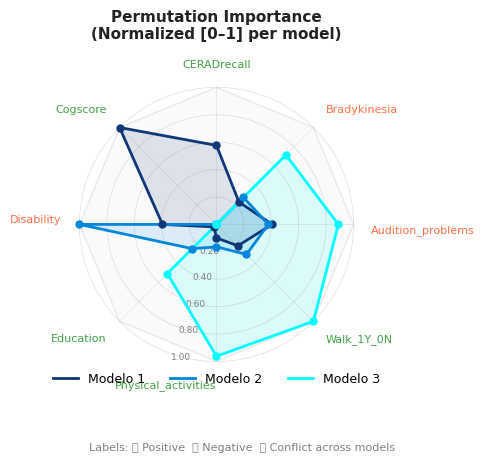

In [ ]:
# By maximum importance across models (default)
#plot_multi_radial_importance(datasets, var_order='max_importance')

# By average importance across models
#plot_multi_radial_importance(datasets, var_order='mean_importance')

import matplotlib.pyplot as plt
# Alphabetical
plot_multi_radial_importance(datasets, var_order='alphabetical')
# Manual — you decide the exact order on the radar chart
#plot_multi_radial_importance(datasets, var_order=['VarC', 'VarA', 'VarF', 'VarB'])

✅ Todas las variables compartidas tienen dirección consistente.


C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: U

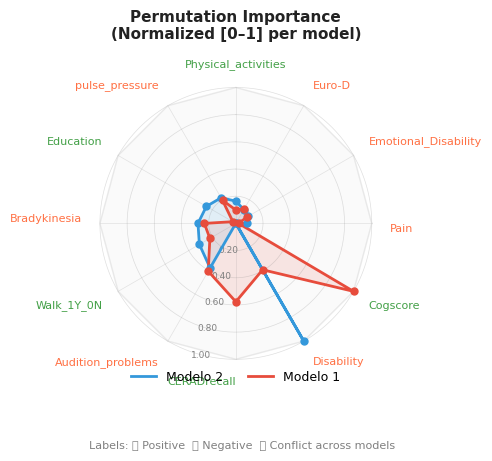

In [33]:
plot_multi_radial_importance([
    {
    'df': df_final_wo_used_diag_vars,
    'importance': perm_importance_avg_wo_used_diag_vars,
    'features': best_features_wo_used_diag_vars,
    'label': 'Modelo 2',
    'color': '#3498db'  # azul
  },
  {
    'df': df_final,
    'importance': perm_importance_avg, # pd.Series, index=nombre variable
    'features': best_features,
    'label': 'Modelo 1',
    'color': '#e74c3c'  # rojo
  },

], top_n=10)

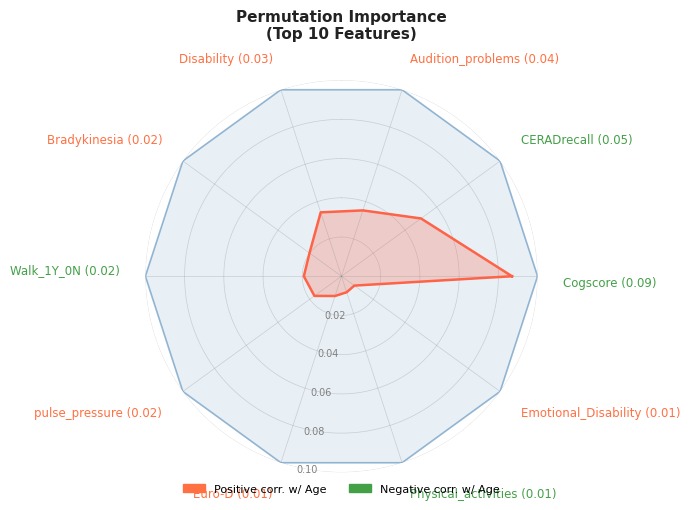

In [34]:
combined_df = plot_signed_perm_importance_radial(df_final, 
                     perm_importance_avg, best_features)


In [35]:
#perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp.parquet")["perm_importance"]


In [36]:
#perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp.parquet")["perm_importance"]


In [37]:
#perm_importance_avg.shape

In [38]:
#df_final.columns

In [39]:
best_features

['Family_dementia_any',
 'Sex_1F_2M',
 'Education',
 'Disability',
 'Assets',
 'Ataxia',
 'Bradykinesia',
 'Hypertension_1Y_0N',
 'Heart_Disease_1Y_0N',
 'Vision_problems',
 'Audition_problems',
 'Cogscore',
 'CERADrecall',
 'DSMIV',
 'ICD10',
 'Euro-D',
 'pulse_pressure',
 'orthostatic_drop',
 'Stroke_1Y_0N',
 'Back_diseases',
 'SRQ',
 'NPI severity score',
 'Arthritis',
 'Breathlessness',
 'Breath_problems',
 'Angina',
 'Stomach_problems',
 'Faints',
 'Paralysis',
 'Skin_disorder',
 'Pain',
 'Emotional_Disability',
 'Physical_activities',
 'Walk_1Y_0N',
 'Exercise_increase',
 'Medications_1Y_0N']

## Features Only controls

In [40]:
import pickle


In [41]:
pkl_path="SFS/best_features-all-vars_all-subjects_onlyCN.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)
  
perm_importance_avg = pd.read_parquet("Results/all-vars_all-subjects-perm_imp_onlyCN.parquet")["perm_importance"]
perm_importance_avg;


In [42]:
df_final_wo_used_diag_vars = pd.read_parquet('Results/wo-used-diag-vars_all-subjects_onlyCN.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars_all-subjects_onlyCN.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars = pd.read_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp_onlyCN.parquet")["perm_importance"]


In [43]:
df_final_wo_used_diag_vars_and_funct_vars = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects_onlyCN.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects_onlyCN.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars_and_funct_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars_and_funct_vars = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp_onlyCN.parquet")["perm_importance"]


In [44]:
datasets = [
  {
    'df': df_final,
    'importance': perm_importance_avg, # pd.Series, index=nombre variable
    'features': best_features,
    'label': 'Modelo 1',
    'color': '#103778'  # rojo
  },
    {
    'df': df_final_wo_used_diag_vars,
    'importance': perm_importance_avg_wo_used_diag_vars,
    'features': best_features_wo_used_diag_vars,
    'label': 'Modelo 2',
    'color': '#0387DB'  # azul
  },  
    {
    'df': df_final_wo_used_diag_vars_and_funct_vars,
    'importance': perm_importance_avg_wo_used_diag_vars_and_funct_vars,
    'features': best_features_wo_used_diag_vars_and_funct_vars,
    'label': 'Modelo 3',
    'color': '#00FFFF'  # azul
  }


]

✅ Todas las variables compartidas tienen dirección consistente.


C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_52236\855275477.py:195: U

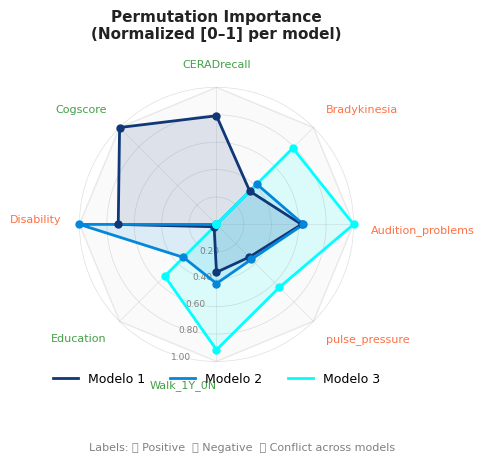

In [ ]:
# By maximum importance across models (default)
#plot_multi_radial_importance(datasets, var_order='max_importance')

# By average importance across models
#plot_multi_radial_importance(datasets, var_order='mean_importance')

import matplotlib.pyplot as plt
# Alphabetical
plot_multi_radial_importance(datasets, var_order='alphabetical', name = 'RadialPlotWave1OnlyHC' )
# Manual — you decide the exact order on the radar chart
#plot_multi_radial_importance(datasets, var_order=['VarC', 'VarA', 'VarF', 'VarB'])

## Longitudinal

In [46]:
df_final = pd.read_parquet('Results/all-vars_all-subjects-Incidence.parquet')

In [47]:
df_final.shape

(8391, 40)

In [48]:
Counter(df_final.Sex_1F_2M)

Counter({2.0: 2857, 1.0: 5528, 1.3407274895646988: 6})

In [49]:
8174/(8174 + 4518)

0.6440277340056728

In [50]:
print(df_final.Age.mean().round(2), df_final.Age.std().round(2))
Counter(df_final.Sex_1F_2M)

77.84 6.56


Counter({2.0: 2857, 1.0: 5528, 1.3407274895646988: 6})

In [51]:
from collections import Counter
data_for_stats = df_final.copy()
data_for_stats['Education'] = data_for_stats['Education'].replace({0:'None/Elementary school', 
                                  1:'None/Elementary school', 
                                  2:'Middle/High school', 
                                  3:'Middle/High school', 
                                  4:'College'})


data_for_stats['CountriesUnique'] = data_for_stats['Countries'].replace({'Peru (urban)':'Peru', 
                                     'Peru (rural)':'Peru', 
                                     'Mexico (rural)':'Mexico', 
                                     'Mexico (urban)':'Mexico'})


display(Counter(data_for_stats.dropna(subset=['Education']).Education))

Counter({'Middle/High school': 4225,
         'College': 1016,
         'None/Elementary school': 3103,
         1.9773489932885906: 47})

#### Global summary 

In [52]:
edu_counts = (data_for_stats['Education']
       .loc[data_for_stats['Education'].isin(['None/Elementary school', 'Middle/High school', 'College'])]
       .value_counts(normalize=True) * 100)

total_summary = pd.Series({
  'N': len(data_for_stats),
  'Age mean': data_for_stats['Age'].mean().round(2),
  'Age std': data_for_stats['Age'].std().round(2),
  'Age min': data_for_stats['Age'].min(),
  'Age max': data_for_stats['Age'].max(),
  'N Female': (data_for_stats['Sex_1F_2M'] == 1).sum(),
  '% Female': (100 * (data_for_stats['Sex_1F_2M'] == 1).mean()).round(1),
  '% None/Elementary school': round(edu_counts.get('None/Elementary school', 0), 1),
  '% Middle/High school': round(edu_counts.get('Middle/High school', 0), 1),
  '% College': round(edu_counts.get('College', 0), 1),
  'N Dementia': data_for_stats['anydem'].sum(),                  # <-- add
  '% Dementia': round(100 * data_for_stats['anydem'].mean(), 1)          # <-- add
})

total_summary

In [53]:
37.20+50.60+12.20

100.00000000000001

In [54]:
def country_summary(x):
  d = {
    'N': len(x),
    'Age mean': x['Age'].mean().round(2),
    'Age std': x['Age'].std().round(2),
    'Age min': x['Age'].min(),
    'Age max': x['Age'].max(),
    'N Female': (x['Sex_1F_2M'] == 1).sum(),
    '% Female': (100 * (x['Sex_1F_2M'] == 1).mean()).round(1),
    'N Dementia': x['anydem'].sum(),
    '% Dementia': round(100 * x['anydem'].mean(), 1)
  }
  edu_counts = x['Education'].value_counts(normalize=True) * 100
  for level in ['None/Elementary school', 'Middle/High school', 'College']:
    d[f'% {level}'] = round(edu_counts.get(level, 0), 1)
  return pd.Series(d)

summary = data_for_stats.groupby('CountriesUnique').apply(country_summary)
display(summary)

,N,Age mean,Age std,Age min,Age max,N Female,% Female,N Dementia,% Dementia,% None/Elementary school,% Middle/High school,% College
CountriesUnique,,,,,,,,,,,,
Cuba,1970.0,78.36,6.34,67.0,101.0,1308.0,66.4,256.0,13.2,22.8,59.6,17.3
DR,1170.0,78.96,6.66,68.0,100.0,808.0,69.1,213.0,18.3,69.4,26.0,3.9
Mexico,1455.0,76.70,6.22,67.0,100.0,940.0,64.6,213.0,14.6,69.6,25.1,5.4
Peru,1309.0,77.49,6.90,66.0,100.0,817.0,62.4,143.0,11.0,18.7,64.3,16.0
Puerto Rico,1238.0,79.49,6.49,68.0,101.0,846.0,68.3,190.0,15.6,19.7,57.1,22.8
Venezuela,1249.0,76.00,6.23,68.0,99.0,809.0,64.8,183.0,14.7,27.2,66.6,4.8


In [55]:
24.8+58.2+17

100.0

In [ ]:
import pandas as pd

df = data_for_stats[['Sex_1F_2M', 'Age', 'CountriesUnique', 'Education', 'anydem']].copy()

# Avoid "duplicates" by spaces / variants
df['CountriesUnique'] = df['CountriesUnique'].astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# -------- Age mean (SD)
age_agg = df.groupby('CountriesUnique')['Age'].agg(['mean', 'std'])
age_stats = (age_agg['mean'].round(1).astype(str) +
       " (" + age_agg['std'].round(1).astype(str) + ")").rename('Age mean (SD)')

# -------- N (% Female)
sex_agg = df.groupby('CountriesUnique')['Sex_1F_2M'].agg(
  N='size',
  pct_female=lambda s: s.eq(1).mean() * 100
)
n_stats = (sex_agg['N'].astype(int).astype(str) +
      " (" + sex_agg['pct_female'].round(1).astype(str) + "%)").rename('N (% Female)')

# -------- N Dementia (% Dementia)
dem_agg = df.groupby('CountriesUnique')['anydem'].agg(
  n_dem='sum',
  pct_dem=lambda s: s.mean() * 100
)
dem_stats = (dem_agg['n_dem'].astype(int).astype(str) +
       " (" + dem_agg['pct_dem'].round(1).astype(str) + "%)").rename('N Dementia (%)')

# -------- Education % (Education is string)
edu = df[['CountriesUnique', 'Education']].copy()
edu['Education'] = edu['Education'].astype(str).str.strip()

# Exclude the value "1.9365..." even if it comes as string (or with spaces)
bad_val = "1.9773489932885906"
edu = edu.loc[edu['Education'].notna() & (edu['Education'] != bad_val)]

counts = edu.groupby(['CountriesUnique', 'Education']).size()
pct = counts / counts.groupby(level=0).transform('sum') * 100
edu_stats = (pct.unstack('Education')
        .round(1)
        .astype(str)
        .add('%'))

# -------- Final Merge
table = pd.concat([age_stats, n_stats, dem_stats, edu_stats], axis=1)
table

In [57]:
edu_stats = (pct.unstack('Education')
        .round(3)
        .astype(str)
        .add('%'))
edu_stats


Education,College,Middle/High school,None/Elementary school
CountriesUnique,,,
Cuba,17.345%,59.766%,22.889%
DR,3.959%,26.162%,69.88%
Mexico,5.361%,25.086%,69.553%
Peru,16.127%,64.969%,18.904%
Puerto Rico,22.871%,57.34%,19.789%
Venezuela,4.87%,67.532%,27.597%


In [36]:
table.to_excel('demo_long.xlsx')

#### Features wave 2

In [55]:
pkl_path="SFS/best_features-all-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)
  
perm_importance_avg = pd.read_parquet("Results/all-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]
perm_importance_avg;


In [56]:
df_final_wo_used_diag_vars = pd.read_parquet('Results/wo-used-diag-vars_all-subjects-Incidence.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars = pd.read_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]


In [57]:
df_final_wo_used_diag_vars_and_funct_vars = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects-Incidence.parquet')

pkl_path="SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects-Incidence.pkl"

with open(pkl_path, "rb") as f:
    best_features_wo_used_diag_vars_and_funct_vars = pickle.load(f)

perm_importance_avg_wo_used_diag_vars_and_funct_vars = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp-Incidence.parquet")["perm_importance"]


In [58]:
datasets = [
  {
    'df': df_final,
    'importance': perm_importance_avg, # pd.Series, index=nombre variable
    'features': best_features,
    'label': 'Modelo 1',
    'color': '#103778'  # rojo
  },
    {
    'df': df_final_wo_used_diag_vars,
    'importance': perm_importance_avg_wo_used_diag_vars,
    'features': best_features_wo_used_diag_vars,
    'label': 'Modelo 2',
    'color': '#0387DB'  # azul
  },  
    {
    'df': df_final_wo_used_diag_vars_and_funct_vars,
    'importance': perm_importance_avg_wo_used_diag_vars_and_funct_vars,
    'features': best_features_wo_used_diag_vars_and_funct_vars,
    'label': 'Modelo 3',
    'color': '#00FFFF'  # azul
  }


]

✅ Todas las variables compartidas tienen dirección consistente.


C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: U

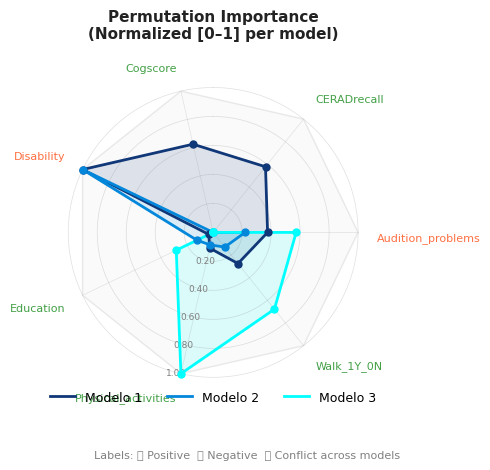

In [ ]:
# By maximum importance across models (default)
#plot_multi_radial_importance(datasets, var_order='max_importance')

# By average importance across models
#plot_multi_radial_importance(datasets, var_order='mean_importance')

import matplotlib.pyplot as plt
# Alphabetical
plot_multi_radial_importance(datasets, var_order='alphabetical', name='RadialPlotWave2')
# Manual — you decide the exact order on the radar chart
#plot_multi_radial_importance(datasets, var_order=['VarC', 'VarA', 'VarF', 'VarB'])

✅ Todas las variables compartidas tienen dirección consistente.


C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from current font.
  plt.savefig('Figures/' + name + '.pdf', format='pdf', bbox_inches='tight', dpi=300)
C:\Users\herna\AppData\Local\Temp\ipykernel_34984\855275477.py:195: U

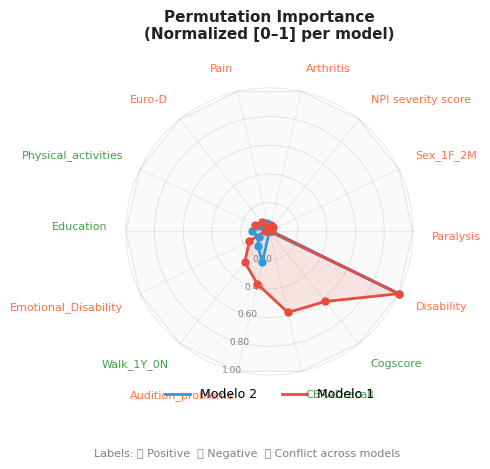

In [42]:
plot_multi_radial_importance([
    {
    'df': df_final_wo_used_diag_vars,
    'importance': perm_importance_avg_wo_used_diag_vars,
    'features': best_features_wo_used_diag_vars,
    'label': 'Modelo 2',
    'color': '#3498db'  # azul
  },
  {
    'df': df_final,
    'importance': perm_importance_avg, # pd.Series, index=nombre variable
    'features': best_features,
    'label': 'Modelo 1',
    'color': '#e74c3c'  # rojo
  },

], top_n=10)

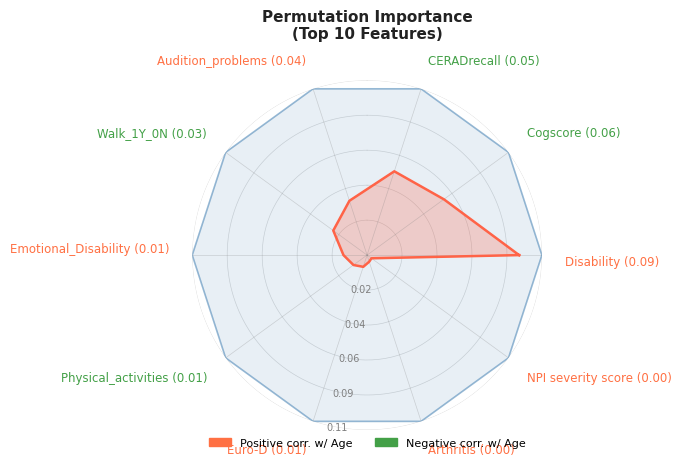

In [43]:
combined_df = plot_signed_perm_importance_radial(df_final, 
                     perm_importance_avg, best_features)


#### Density plot

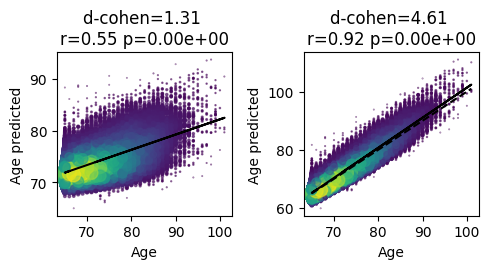

In [8]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [8]:
import pickle
pkl_path="SFS/best_features-all-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [9]:
perm_importance_avg = pd.read_parquet("Results/all-vars_all-subjects-perm_imp.parquet")["perm_importance"]


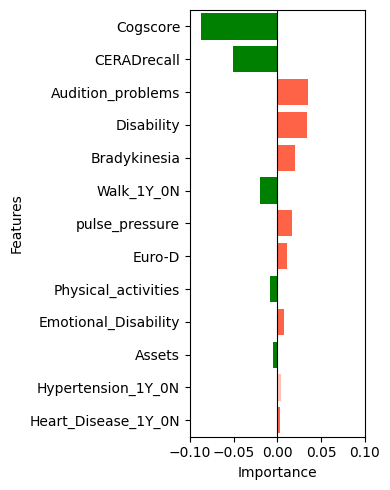

In [22]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     xlim=(-0.1, 0.1), ylim=(22.5, 35.5))


#### AnyDem comparision

N 2188 1094 1094
cliff delta 0.7868 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,0.0,0.7868,0.0,0.0,0.0


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


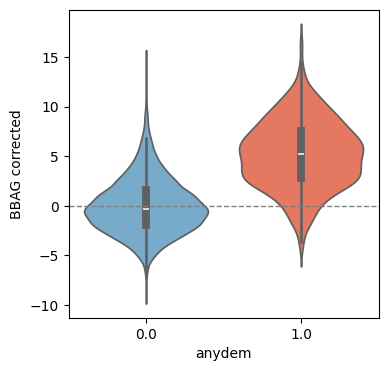

In [12]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

N 918 459 459
cliff delta 0.8079 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1,0,0.8079,0.0,0.0,6.333616e-195


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


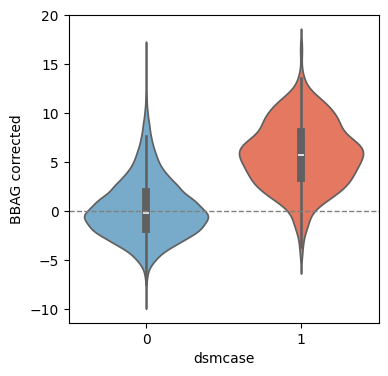

In [13]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

N 5400 2700 2700
cliff delta 0.7549 0.0
Computing permutations...
N 2432 1216 1216
cliff delta 0.4536 0.0
Computing permutations...
N 2432 1216 1216
cliff delta -0.4117 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,3,1,0.7549,0.0,0.0,0.000000e+00
1,3,2,0.4536,0.0,0.0,2.381487e-129
2,1,2,0.4117,0.0,0.0,8.721611e-130


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


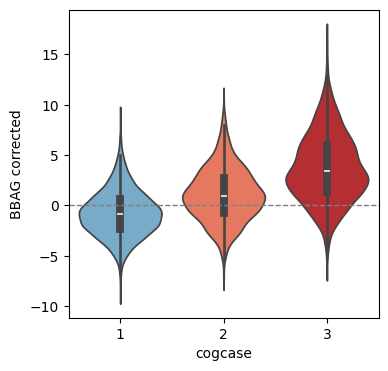

In [14]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")

### filtered subjects

In [15]:
df_final = pd.read_parquet('Results/all-vars_filtered-subjects.parquet')

#### Density plot

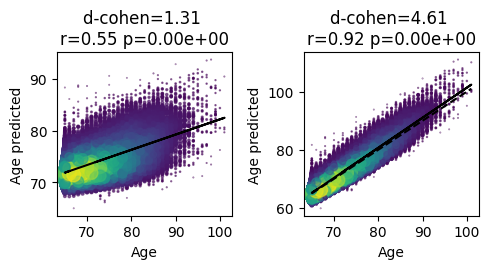

In [16]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [ ]:
import pickle
pkl_path="SFS/best_features-all-vars_filtered-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [ ]:
perm_importance_avg = pd.read_parquet("Results/all-vars_filtered-subjects-perm_imp.parquet")["perm_importance"]


In [ ]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     xlim=(-0.09, 0.09), ylim=(10.5, 30.5))


#### AnyDem comparision

In [ ]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

In [ ]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

In [ ]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")

## All wo-used-diag-vars

### all subjects

In [23]:
df_final = pd.read_parquet('Results/wo-used-diag-vars_all-subjects.parquet')

#### Density plot

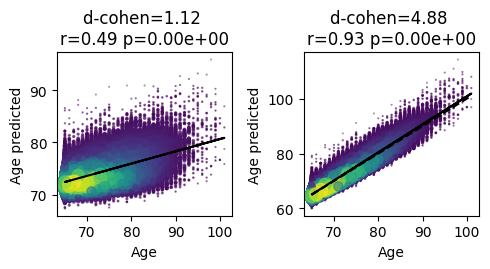

In [14]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [24]:
import pickle
pkl_path="SFS/best_features-wo-used-diag-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [25]:
perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp.parquet")["perm_importance"]


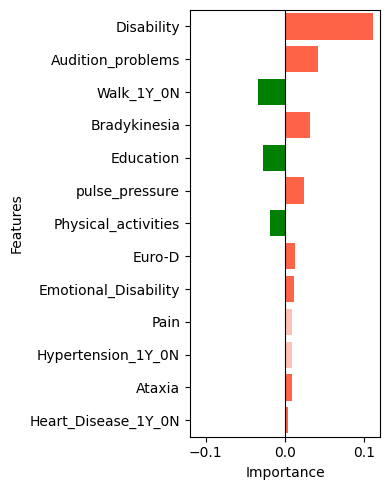

In [30]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features,
                     xlim=(-0.12, 0.12), ylim=(8.5, 21.5))


#### AnyDem comparision

N 2188 1094 1094
cliff delta 0.4928 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,0.0,0.4928,0.0,0.0,1.356686e-155


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


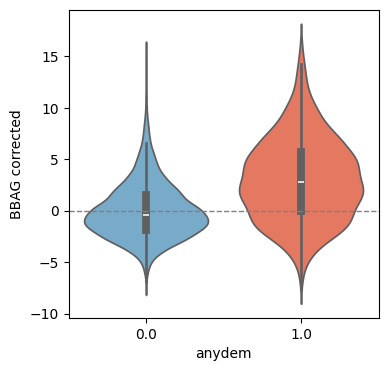

In [18]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

N 920 460 460
cliff delta 0.5717 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1,0,0.5717,0.0,0.0,1.007955e-101


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


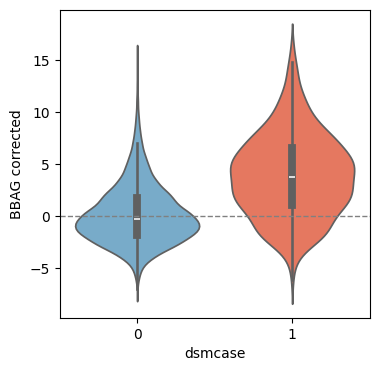

In [19]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

N 5372 2686 2686
cliff delta 0.4013 0.0
Computing permutations...
N 2408 1204 1204
cliff delta 0.23 0.0
Computing permutations...
N 2408 1204 1204
cliff delta -0.167 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,3,1,0.4013,0.0,0.0,1.048786e-204
1,3,2,0.2300,0.0,0.0,7.460213e-33
2,1,2,0.1670,0.0,0.0,4.417629e-20


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


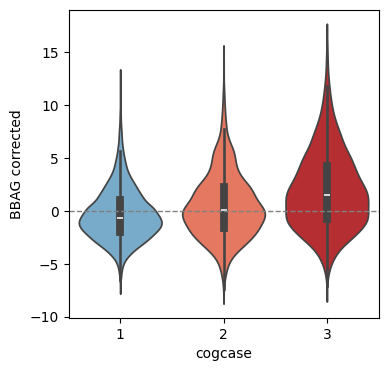

In [20]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")

### filtered subjects

In [26]:
df_final = pd.read_parquet('Results/wo-used-diag-vars_filtered-subjects.parquet')

#### Density plot

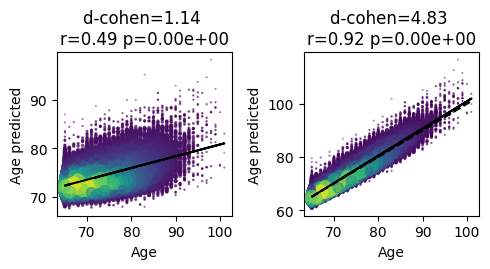

In [27]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [28]:
import pickle
pkl_path="SFS/best_features-wo-used-diag-vars_all-subjects.pkl"
all
with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [29]:
perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars_filtered-subjects-perm_imp.parquet")["perm_importance"]


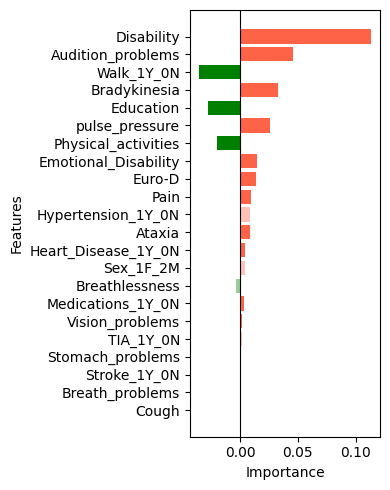

In [33]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     )


#### AnyDem comparision

N 2016 1008 1008
cliff delta 0.5144 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,0.0,0.5144,0.0,0.0,3.927126e-156


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


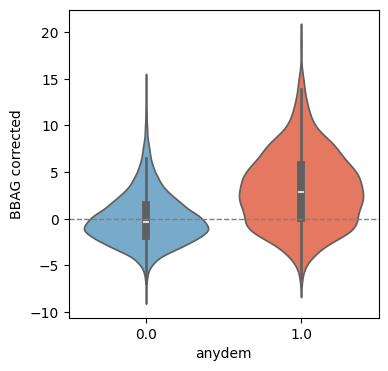

In [31]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

N 860 430 430
cliff delta 0.6167 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1,0,0.6167,0.0,0.0,4.993348e-102


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


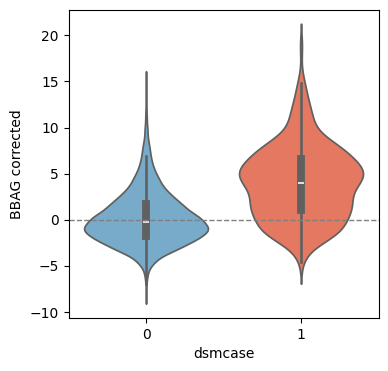

In [32]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

In [ ]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")

## All wo-used-diag-vars-and-funct-vars 

### all subjects

In [31]:
df_final = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_all-subjects.parquet')

#### Density plot

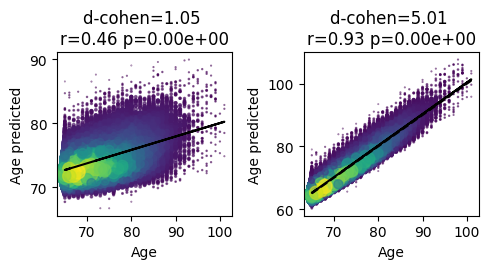

In [22]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [32]:
import pickle
pkl_path="SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects.pkl"

with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [33]:
perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_all-subjects-perm_imp.parquet")["perm_importance"]


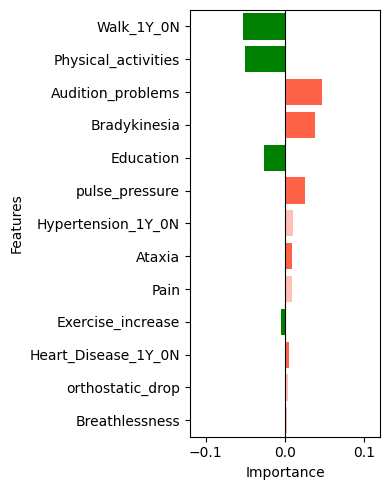

In [38]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, 
                     xlim=(-0.12, 0.12), ylim=(10.5, 23.5))


#### AnyDem comparision

N 2196 1098 1098
cliff delta 0.423 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,0.0,0.423,0.0,0.0,3.403692e-117


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


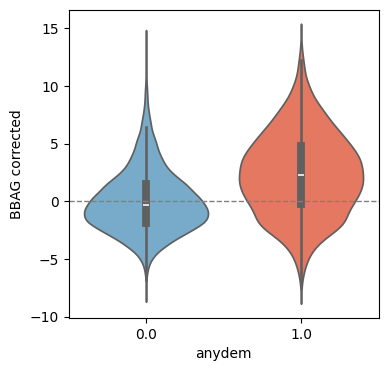

In [26]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

N 924 462 462
cliff delta 0.4647 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1,0,0.4647,0.0,0.0,8.596146e-69


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


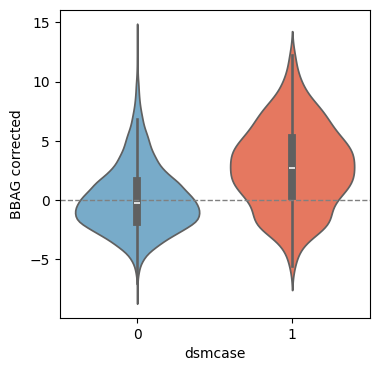

In [27]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

N 5400 2700 2700
cliff delta 0.3678 0.0
Computing permutations...
N 2420 1210 1210
cliff delta 0.2037 0.0
Computing permutations...
N 2420 1210 1210
cliff delta -0.1673 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,3,1,0.3678,0.0,0.0,1.305436e-174
1,3,2,0.2037,0.0,0.0,3.161088e-23
2,1,2,0.1673,0.0,0.0,1.410510e-20


C:\Users\herna\AppData\Local\Temp\ipykernel_33076\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


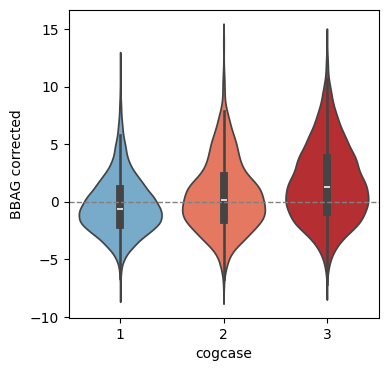

In [28]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")

### filtered subjects

In [46]:
df_final = pd.read_parquet('Results/wo-used-diag-vars-and-funct-vars_filtered-subjects.parquet')

#### Density plot

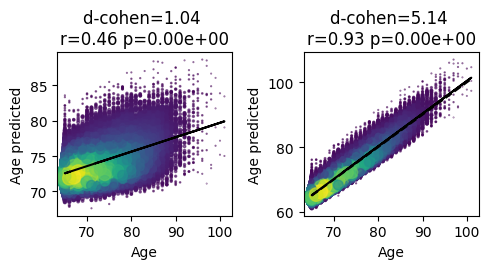

In [47]:
plot_pred_vs_true_density(df_final)


#### Features importance

In [48]:
import pickle
pkl_path="SFS/best_features-wo-used-diag-vars-and-funct-vars_all-subjects.pkl"
all
with open(pkl_path, "rb") as f:
    best_features = pickle.load(f)

In [49]:
perm_importance_avg = pd.read_parquet("Results/wo-used-diag-vars-and-funct-vars_filtered-subjects-perm_imp.parquet")["perm_importance"]


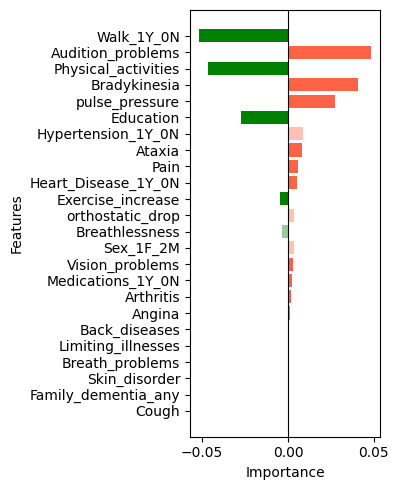

In [50]:
combined_df = plot_signed_perm_importance(df_final, 
                     perm_importance_avg, best_features, )
                     #xlim=(-0.09, 0.09), ylim=(10.5, 26.5))


#### AnyDem comparision

N 1904 952 952
cliff delta 0.4748 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1.0,0.0,0.4748,0.0,0.0,2.842956e-125


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


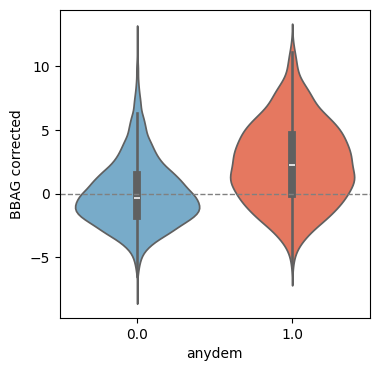

In [51]:
results_df = violin_mannwhitney_cliff(df_final, group_col="anydem")


#### Dsmcase comparision

N 812 406 406
cliff delta 0.5066 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,1,0,0.5066,0.0,0.0,3.468728e-69


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',
C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


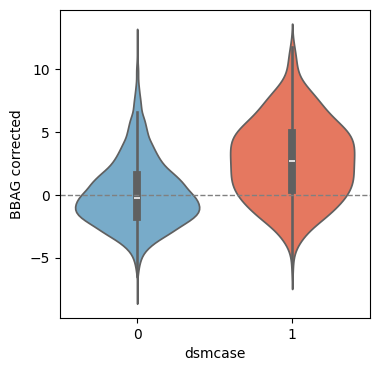

In [52]:
results_df = violin_mannwhitney_cliff(df_final, group_col="dsmcase")


#### Cogcase comparision

N 5112 2556 2556
cliff delta 0.3758 0.0
Computing permutations...
N 2416 1208 1208
cliff delta 0.2083 0.0
Computing permutations...
N 2416 1208 1208
cliff delta -0.1727 0.0
Computing permutations...


,Group1,Group2,cliff_delta 1.5*IQR (0.15_S | 0.33_M | 0.47_L),CI 1.5*IQR (0.15_S | 0.33_M | 0.47_L),p-value 100000 perm,p-value mann whitney
0,3,1,0.3758,0.0,0.0,2.754633e-174
1,3,2,0.2083,0.0,0.0,3.418184e-24
2,1,2,0.1727,0.0,0.0,4.541709e-20


C:\Users\herna\AppData\Local\Temp\ipykernel_74108\2476734783.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_final, x=group_col, y='GAP_corrected', inner='box',


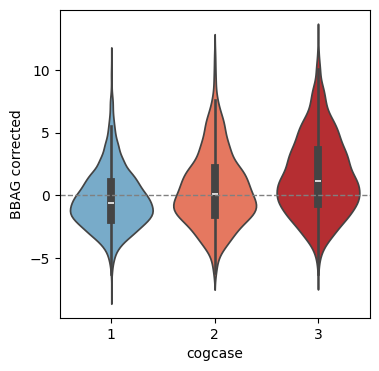

In [53]:
results_df = violin_mannwhitney_cliff(df_final, group_col="cogcase")